# Coursework Assessment: Question 1 
### $ Computability \& Complexity $
---

## Q1(a) — Turing Machine for $1^n 0 1^m \mapsto 1^{n+m}$

### Problem Statement

Design a Turing machine that inputs $1^n 0 1^m$ (a block of $n$ ones, a delimiter zero, and a block of $m$ ones) and outputs $1^{n+m}$ (a single merged block of $n+m$ ones). The machine is initialised scanning the leftmost $1$ in the left block and must halt scanning the leftmost $1$ of the output block.

Tape alphabet: $\{0, 1\}$, where $0$ also serves as the blank symbol.
Permitted actions: L (move left), R (move right), W1 (write 1), W0 (write 0), T (halt).

### Core Idea: Bubble Technique

Treat the delimiter $0$ as a "bubble" and repeatedly apply the local transposition

$$01 \Rightarrow 10$$

which moves $0$ one cell to the right and effectively transfers the leftmost $1$ of the right block into the left block. After $m$ such transpositions the delimiter reaches the right end of all ones (it reads a blank $0$), at which point the tape holds $1^{n+m}$ followed by a blank. The head then returns to the leftmost $1$ and halts.

### State Descriptions

| State | Description |
|---|---|
| `q0` | Scan right across the left block $1^n$ until the delimiter $0$. |
| `qInspect` | Positioned one cell right of the delimiter; decide whether to continue. |
| `qWL`, `qW1`, `qBack`, `qDelim` | Execute one swap step $01 \to 10$ (write-move quartet). |
| `qReturn`, `qGoLeft` | Return leftward to the start of the merged block. |
| `qHalt` | Halt state; head rests on the leftmost $1$ of $1^{n+m}$. |

### Transition Table $\delta$

Each instruction has the form: **(current state, reading, action, next state)**

#### Block A — Scan right to the delimiter

| Current State | Reading | Action | Next State |
|---|---|---|---|
| `q0` | 1 | R | `q0` |
| `q0` | 0 | R | `qInspect` |

#### Block B — Bubble the delimiter rightward by performing $01 \to 10$

**Case 1:** symbol to the right of the delimiter is `1` — perform one swap:

| Current State | Reading | Action | Next State |
|---|---|---|---|
| `qInspect` | 1 | W0 | `qWL` |
| `qWL` | 0 | L | `qW1` |
| `qW1` | 0 | W1 | `qBack` |
| `qBack` | 1 | R | `qDelim` |
| `qDelim` | 0 | R | `qInspect` |

**Case 2:** symbol to the right of the delimiter is `0` — no more ones remain, stop:

| Current State | Reading | Action | Next State |
|---|---|---|---|
| `qInspect` | 0 | L | `qReturn` |

#### Block C — Return to the leftmost `1` and halt

| Current State | Reading | Action | Next State |
|---|---|---|---|
| `qReturn` | 0 | L | `qGoLeft` |
| `qGoLeft` | 1 | L | `qGoLeft` |
| `qGoLeft` | 0 | R | `qHalt` |
| `qHalt` | 1 | T | `qHalt` |

### Correctness Sketch

Initially the delimiter has $n$ ones to its left and $m$ ones to its right. Each complete Block B pass moves the delimiter one cell right, growing the left block by one. After exactly $m$ passes the delimiter is immediately followed by a blank, triggering Case 2; the tape at that point contains exactly $n+m$ consecutive ones, satisfying the output specification. Block C guarantees the head terminates on the first of those ones.

**Step-count analysis:** Block A uses $n$ steps; Block B uses $O(m)$ constant-length passes; Block C uses $O(n+m)$ steps. Total: $O(nm + n + m)$, which is polynomial in the input length $n + m + 1$.

---
## Q1(b) - Turing Machine Coding

In [1]:
# ==================== Q1(b) ====================
import random

def build_tm_transitions():
# Build and return the full TM transition table that encodes the 1^n 0 1^m -> 1^(n+m) behavior.
    """
    Transition function of the Turing machine.
    Tape alphabet: {'0', '1'}, where '0' is also used as blank.
    Actions: L, R, W1, W0, T (halt).
    """
    delta = {}

# A: Scan right in the left block 1^n until the delimiter 0.
    delta[("q0", "1")] = ("R", "q0")
    delta[("q0", "0")] = ("R", "qInspect")

# B: Move the delimiter 0 rightward by repeatedly applying 01 -> 10.
    delta[("qInspect", "1")] = ("W0", "qWL")
    delta[("qWL", "0")] = ("L", "qW1")
    delta[("qW1", "0")] = ("W1", "qBack")
    delta[("qBack", "1")] = ("R", "qDelim")
    delta[("qDelim", "0")] = ("R", "qInspect")

# Stop bubbling when no 1 exists to the right.
    delta[("qInspect", "0")] = ("L", "qReturn")

# C: Return to the leftmost 1 and halt.
    delta[("qReturn", "0")] = ("L", "qGoLeft")
    delta[("qGoLeft", "1")] = ("L", "qGoLeft")
    delta[("qGoLeft", "0")] = ("R", "qHalt")
    delta[("qHalt", "1")] = ("T", "qHalt")

    return delta

def ensure_tape_cell(tape, head):
# Guarantee head points to a valid cell by extending tape left/right with blank symbol '0' when out of bounds.
    """
    Ensure tape[head] is valid by extending the tape with '0' when needed.
    """
    while head < 0:
        tape.insert(0, "0")
        head += 1
    while head >= len(tape):
        tape.append("0")
    return tape, head

def run_tm(input_str, transitions=None, max_steps=1_000_000, verbose=False):
# Execute the TM step-by-step on input string and return output plus final machine state details.
    """
    Simulate input 1^n 0 1^m and output merged 1^{n+m}.
    Return (output_ones, final_tape, final_head, steps_used).
    """
    if transitions is None:
        transitions = build_tm_transitions()

    if not input_str or input_str[0] != "1":
        raise ValueError("Input tape must start with '1'.")

    # Add one trailing blank '0' to simplify right-side checks.
    tape = list(input_str) + ["0"]
    head = 0
    state = "q0"
    steps = 0

    while steps < max_steps:
        tape, head = ensure_tape_cell(tape, head)
        sym = tape[head]

        transition = transitions.get((state, sym))
        if transition is None:
            raise RuntimeError(f"No transition for state={state}, sym={sym}, head={head}.")
        action, next_state = transition

        if verbose:
            left = max(0, head - 10)
            right = min(len(tape), head + 11)
            print(f"step={steps:6d} state={state:8s} read={sym} action={action:2s} next={next_state:8s}")
            print("".join(tape[left:right]))
            print(" " * (head - left) + "^")

        if action == "L":
            head -= 1
        elif action == "R":
            head += 1
        elif action == "W1":
            tape[head] = "1"
        elif action == "W0":
            tape[head] = "0"
        elif action == "T":
            break
        else:
            raise ValueError(f"Action Error")

        state = next_state
        steps += 1
    else:
        raise RuntimeError("Steps Error")

    if "1" not in tape:
        return "", tape, head, steps
    first_one = tape.index("1")

    j = first_one
    while j < len(tape) and tape[j] == "1":
        j += 1
    output = "".join(tape[first_one:j])
    return output, tape, head, steps

# ------------------------------------------------------------------
# Q1(b) — Explicit demonstration on two concrete test cases
# Case 1: n=3, m=2  -> input  "111 0 11",  expected output "11111"
# Case 2: n=1, m=4  -> input  "1 0 1111",  expected output "11111"
# These fixed cases make the TM behaviour easy to verify by inspection.
# ------------------------------------------------------------------
demo_cases = [
    ("1110" + "11",  3, 2),   # n=3, m=2 -> 1^5
    ("10" + "1111",  1, 4),   # n=1, m=4 -> 1^5
    ("111",          3, 0),   # n=3, m=0 (no right block) -> 1^3
]
print("="*60)
print("Q1(b) explicit demonstration")
print("="*60)
for input_str, n, m in demo_cases:
    output, _, _, steps = run_tm(input_str)
    expected = "1" * (n + m)
    status = "PASS" if output == expected else "FAIL"
    print(f"  Input: {input_str!r:15s} -> output: {output!r:10s} "
          f"(expected {expected!r}) [{status}]  steps={steps}")

# ------------------------------------------------------------------
# Q1(b) — Randomised stress test across 20 cases
# Verifies the TM for arbitrary n in [1,20] and m in [0,20].
# ------------------------------------------------------------------
rng = random.Random(42)
num_tests = 20
max_m = 20
max_n = 20
failed_tests = 0
for _ in range(num_tests):
    n = rng.randint(1, max_n)  # Enforce leftmost symbol is '1'.
    m = rng.randint(0, max_m)
    input_str = "1" * n + "0" + "1" * m
    if input_str[0] != "1":
        failed_tests += 1
        print(f"Test failed: invalid random tape {input_str}")
        continue
    output, final_tape, final_head, steps = run_tm(input_str)
    expected_output = "1" * (n + m)
    if output != expected_output:
        failed_tests += 1
        print(
            f"Test failed: input={input_str}, expected={expected_output}, got={output}, "
            f"head={final_head}, steps={steps}"
        )
if failed_tests == 0:
    print(f"{num_tests} Random tests passed.")
else:
    print(f"{failed_tests}/{num_tests} Random tests failed.")
    

Q1(b) explicit demonstration
  Input: '111011'        -> output: '11111'    (expected '11111') [PASS]  steps=22
  Input: '101111'        -> output: '11111'    (expected '11111') [PASS]  steps=30
  Input: '111'           -> output: '111'      (expected '111') [PASS]  steps=10
20 Random tests passed.


---

## Q1(c) — Show that $\lceil\log_2(n+1)\rceil$ is a recursive function for $n \in \mathbb{N}$

**Claim:** The function $f(n) = \lceil\log_2(n+1)\rceil$ is recursive (in fact, primitive recursive).

**Strategy:** Represent $f$ as a bounded minimisation ($\mu$-operator) applied to a primitive recursive predicate, and invoke the closure of bounded minimisation under primitive recursion.

---
### Step 1 — Reformulate as bounded minimisation

Observe that $\lceil\log_2(n+1)\rceil$ is precisely the least non-negative integer $k$ satisfying $2^k \geq n+1$, so

$$f(n) = \min\{\, k : 2^k \geq n+1 \,\}$$

Introduce the binary predicate $P(n, k) = 1$ if $2^k \geq n+1$, else $P(n, k) = 0$.

Then $f(n) = \mu k\, [\, P(n, k) = 1 \,]$.

---
### Step 2 — Show $P(n, k)$ is primitive recursive

Each constituent function is verified to be primitive recursive:

1. The successor function $S(n) = n+1$ is primitive recursive (one of the base functions).
2. Addition and multiplication are primitive recursive (standard results).
3. The power-of-two function $\text{pow2}(k) = 2^k$ is primitive recursive, defined by:

$$\text{pow2}(0) = 1, \qquad \text{pow2}(k+1) = 2 \cdot \text{pow2}(k)$$

4. Truncated subtraction $x \mathbin{\dot{-}} y = \max(x - y,\, 0)$ is primitive recursive (standard).
5. The zero-test $\text{isZero}(t) = \begin{cases} 1 & \text{if } t = 0 \\ 0 & \text{otherwise} \end{cases}$ is primitive recursive.
6. The greater-or-equal predicate $\text{GE}(x, y) = \text{isZero}(y \mathbin{\dot{-}} x) = 1$ iff $x \geq y$ is a composition of primitive recursive functions, hence primitive recursive.
7. Therefore $P(n, k) = \text{GE}(\text{pow2}(k),\, S(n))$ is primitive recursive as a composition.

---
### Step 3 — Verify the search is bounded

For every $n \in \mathbb{N}$ one has $2^{n+1} \geq n+1$ (proved by induction), so there always exists some $k \leq n+1$ satisfying $P(n, k) = 1$. Consequently the minimisation is bounded:

$$f(n) = \mu k \leq n+1 \;[\; P(n, k) = 1 \;]$$

The search is guaranteed to terminate by $k = n+1$, making it a bounded $\mu$-operator.

---
### Conclusion

$P(n, k)$ is primitive recursive and the search bound is $n+1$; therefore $f$ is obtained by applying a bounded $\mu$-operator to a primitive recursive predicate. Bounded minimisation preserves primitive recursiveness, so $f(n) = \lceil\log_2(n+1)\rceil$ is a **primitive recursive** function, and in particular a **recursive function**. $\blacksquare$

---
## Q1(d) - Binary Search

In [2]:
# ==================== Q1(d) ====================
def binarysearch(lst, target, lower=None, upper=None):
    """
    Recursive binary search on a sorted list.

    The function divides the search interval in half on each recursive call,
    following the algorithm specified in Q1(d):
      - Step 1: initialise lower=0, upper=n-1 on the first call.
      - Step 2: if upper < lower, the target is absent -> return 'fail'.
      - Step 3: middle = floor((lower + upper) / 2).
      - Step 4: if lst[middle] == target, return middle.
      - Step 5: recurse into the left or right half depending on the comparison.

    Parameters
    ----------
    lst    : list, sorted in non-decreasing order
    target : value to locate
    lower  : int, left bound of the current search interval (default: 0)
    upper  : int, right bound of the current search interval (default: len(lst)-1)

    Returns
    -------
    int or str
        Index of target if found; 'fail' otherwise.

    Design decisions
    ----------------
    * Default parameters (lower=None, upper=None) let the caller use the
      two-argument form binarysearch(lst, target) while allowing recursive
      calls to pass updated bounds explicitly.
    * The variable name 'lst' avoids shadowing the built-in 'list'.
    * The recursive structure directly mirrors the algorithm in the question sheet.
    * Step 5 in the question sheet reads "If target < middle then upper = middle-1."
      The symbol 'middle' there is the INDEX (an integer position), but the intended
      comparison is with the LIST VALUE lst[middle].  Comparing a search target against
      a positional index would be meaningless for a general sorted list; the only
      sensible interpretation is target < lst[middle], which is what the code implements.

    Tests
    -----
    See run_tests_Q1_d() below.
    """
    # --- Initialise bounds on the outermost call ---
    if lower is None:
        lower = 0
    if upper is None:
        upper = len(lst) - 1

    # Step 2: base case — search interval is empty
    if upper < lower:
        return "fail"

    # Step 3: compute midpoint (integer division, matches floor)
    middle = (lower + upper) // 2

    # Step 4: base case — target found
    if lst[middle] == target:
        return middle

    # Step 5: recurse into the appropriate half
    if target < lst[middle]:
        # Target lies in the left half; discard everything at and above middle
        return binarysearch(lst, target, lower, middle - 1)
    else:
        # Target lies in the right half; discard everything at and below middle
        return binarysearch(lst, target, middle + 1, upper)

print("="*60)
print("Q1(d) binary search implementation")
print("="*60)

# Random Test for Q1(d)
def run_tests_Q1_d():
    rng = random.Random(42)
    max_len = 30
    value_low = -20
    value_high = 20
    failed = 0
    for i in range(1, num_tests + 1):
        size = rng.randint(0, max_len)
        lst = sorted(rng.randint(value_low, value_high) for _ in range(size))
        # Pick an existing value half of the time, otherwise use a random value.
        if size > 0 and rng.random() < 0.5:
            target = lst[rng.randint(0, size - 1)]
        else:
            target = rng.randint(value_low, value_high)
        out = binarysearch(lst, target)
        expected_indices = [idx for idx, value in enumerate(lst) if value == target]
        if len(expected_indices) == 0:
            if out != "fail":
                failed += 1
                print(f"Test {i} failed: lst={lst}, target={target}, expected=fail, got={out}")
        else:
            if out == "fail" or out not in expected_indices:
                failed += 1
                print(
                    f"Test {i} failed: lst={lst}, target={target}, "
                    f"expected one of {expected_indices}, got={out}"
                )
    if failed == 0:
        print(f"{num_tests} Random tests passed.")
    else:
        print(f"{failed}/{num_tests} Random tests failed.")
run_tests_Q1_d()

Q1(d) binary search implementation
20 Random tests passed.


---

## Q1(e) — Worst-case time complexity of binary search is $O(\log_2 n)$

**Claim:** The binary search algorithm in Q1(d), applied to a sorted list of length $n$, terminates in at most $\lfloor\log_2 n\rfloor + 1$ iterations, giving worst-case time complexity $O(\log_2 n)$.

---
### Key observation: the search interval is halved on every iteration

At any point the algorithm maintains a search interval $[\text{lower},\, \text{upper}]$. Let $L = \text{upper} - \text{lower} + 1$ denote the number of remaining candidates.

Each iteration computes

$$\text{middle} = \left\lfloor \frac{\text{lower} + \text{upper}}{2} \right\rfloor$$

and discards at least half of the candidates:

- If $\text{target} < \text{lst}[\text{middle}]$, set $\text{upper} = \text{middle} - 1$ (retain the left half).
- Otherwise, set $\text{lower} = \text{middle} + 1$ (retain the right half).

In either case the updated interval satisfies

$$L_{\text{new}} \leq \left\lfloor \frac{L}{2} \right\rfloor$$

---
### Iteration count upper bound

Starting from $L_0 = n$, after $k$ iterations:

$$L_k \leq \left\lfloor \frac{n}{2^k} \right\rfloor$$

The algorithm terminates when $L_k = 0$ (empty interval) or when the target is found at the midpoint. A sufficient condition for $L_k = 0$ is

$$\frac{n}{2^k} < 1, \quad \text{i.e.} \quad 2^k > n, \quad \text{i.e.} \quad k > \log_2 n$$

Hence the worst-case number of iterations does not exceed

$$\lfloor\log_2 n\rfloor + 1 = O(\log_2 n)$$

---
### Per-iteration cost

Each iteration performs one midpoint computation (integer division) and at most two comparisons, all $O(1)$ operations independent of $n$.

---
### Conclusion

Combining the iteration bound with the per-step $O(1)$ cost:

$$T(n) = O(1) \times (\lfloor\log_2 n\rfloor + 1) = O(\log_2 n)$$

The worst-case time complexity of binary search (Q1(d)) is $\boldsymbol{O(\log_2 n)}$. 

---
## Q1(f) - Average Number of interations 

Q1(f): binary search iteration counts
20 Random tests passed.

Data (n, avg_iterations):
n=     8  avg_iters=2.6200
n=    16  avg_iters=3.3540
n=    32  avg_iters=4.2150
n=    64  avg_iters=5.1870
n=   128  avg_iters=6.0520
n=   256  avg_iters=7.0270
n=   512  avg_iters=8.0860
n=  1024  avg_iters=8.9530
n=  2048  avg_iters=10.0190
n=  4096  avg_iters=11.0110
n=  8192  avg_iters=12.0010
n= 16384  avg_iters=12.9620
n= 32768  avg_iters=14.0440

avg_iters / log2(n)  (should be roughly constant if O(log2 n)):
n=     8  ratio=0.8733
n=    16  ratio=0.8385
n=    32  ratio=0.8430
n=    64  ratio=0.8645
n=   128  ratio=0.8646
n=   256  ratio=0.8784
n=   512  ratio=0.8984
n=  1024  ratio=0.8953
n=  2048  ratio=0.9108
n=  4096  ratio=0.9176
n=  8192  ratio=0.9232
n= 16384  ratio=0.9259
n= 32768  ratio=0.9363

Polyfit evaluation for O(log2 n) hypothesis:
Model: avg_iters ≈ a * log2(n) + b
a = 0.961868
b = -0.539044
R^2 = 0.999034  (close to 1.0 confirms linear relationship with log2 n)


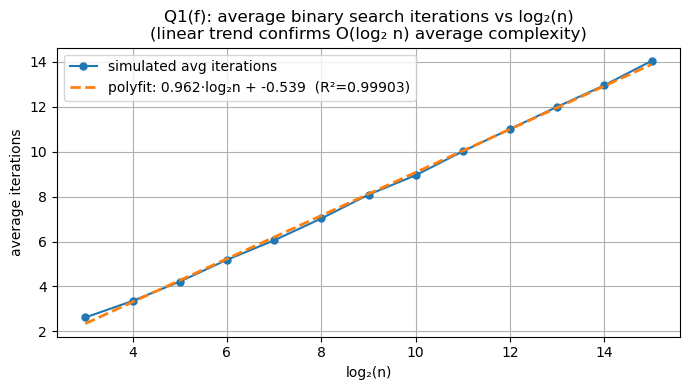

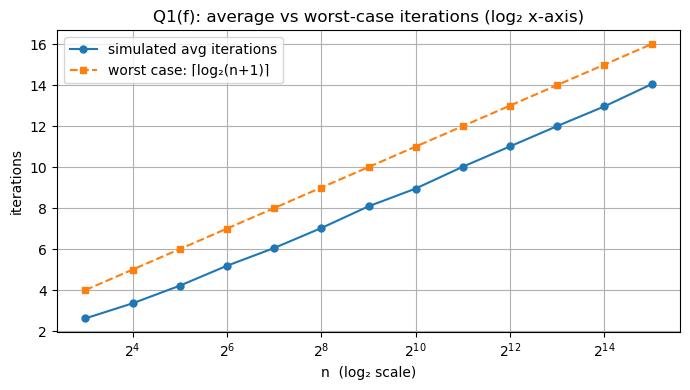

In [3]:
# ==================== Q1(f) ====================
import random
import math
import numpy as np
import matplotlib.pyplot as plt


def binarysearch_count(lst, target):
    """
    Recursive binary search that counts the number of recursive calls made.

    Internally uses a nested helper so that the call count is threaded through
    the recursion as an explicit parameter (pure-functional style, no global
    state or mutable containers).

    Parameters
    ----------
    lst    : list, sorted in non-decreasing order
    target : value to locate

    Returns
    -------
    tuple (result, count)
        result : int index if found, or 'fail'
        count  : int, number of recursive calls including the call that found
                 the target or detected an empty interval.
    """
    def _search(lower, upper, count):
        # Increment the call counter at the start of each recursive call.
        count += 1

        # Base case: empty interval
        if upper < lower:
            return "fail", count

        middle = (lower + upper) // 2

        # Base case: target found
        if lst[middle] == target:
            return middle, count

        # Recurse into left or right half
        if target < lst[middle]:
            return _search(lower, middle - 1, count)
        else:
            return _search(middle + 1, upper, count)

    return _search(0, len(lst) - 1, 0)

def run_tests_Q1_f(num_tests=300, seed=42):
    """
    Random tests for Q1(f): validate correctness and iteration bounds.
    """
    rng = random.Random(seed)
    failed = 0
    randint = rng.randint
    randrange = rng.randrange

    for i in range(1, num_tests + 1):
        n = randint(1, 300)
        lst = sorted(randint(-1000, 1000) for _ in range(n))
        # Hit case only — target is guaranteed to be in the list
        target = lst[randrange(n)]

        out, iters = binarysearch_count(lst, target)

        if out == "fail" or lst[out] != target:
            failed += 1
            print(f"Test {i} failed (hit): target={target}, got={out}")

        max_iters = math.ceil(math.log2(n + 1)) + 1
        if iters < 1 or iters > max_iters:
            failed += 1
            print(
                f"Test {i} failed (iters): n={n}, iters={iters}, "
                f"expected between 1 and {max_iters}"
            )

    print("="*60)
    print("Q1(f): binary search iteration counts")
    print("="*60)

    if failed == 0:
        print(f"{num_tests} Random tests passed.")
    else:
        print(f"{failed}/{num_tests} Random tests failed.")

def simulate_avg_iterations(lengths, trials_per_n=1000, seed=42):
    """
    For each n in lengths, sample random target positions and measure
    average successful-search iterations. Using list = [0, 1, ..., n-1]
    avoids repeated sorting.
    """
    rng = random.Random(seed)
    ns = []
    avg_iters = []

    for n in lengths:
        lst = list(range(n))   # sorted list [0, 1, ..., n-1] — no sorting overhead
        total = sum(binarysearch_count(lst, rng.randrange(n))[1] for _ in range(trials_per_n))

        ns.append(n)
        avg_iters.append(total / trials_per_n)

    return ns, avg_iters

def fit_log_model_with_polyfit(ns, avg_iters):
    """
    Fit avg_iters ≈ a * log2(n) + b with numpy.polyfit and return R^2.
    """
    x = np.log2(np.asarray(ns, dtype=float))
    y = np.asarray(avg_iters, dtype=float)
    a, b = np.polyfit(x, y, 1)
    y_hat = a * x + b

    ss_res = np.sum((y - y_hat) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1.0 - (ss_res / ss_tot if ss_tot != 0 else 0.0)
    return a, b, r2

def report_q1_f_results(ns, avg_iters):
    """
    Print tabular summary and polyfit fit coefficients, then produce two
    diagnostic plots that visually evaluate the O(log2 n) hypothesis.
    """
    print("\nData (n, avg_iterations):")
    for n, av in zip(ns, avg_iters):
        print(f"n={n:6d}  avg_iters={av:.4f}")

    print("\navg_iters / log2(n)  (should be roughly constant if O(log2 n)):")
    log2_ns = [math.log2(n) for n in ns]
    for n, av, log2_n in zip(ns, avg_iters, log2_ns):
        ratio = av / log2_n
        print(f"n={n:6d}  ratio={ratio:.4f}")

    a, b, r2 = fit_log_model_with_polyfit(ns, avg_iters)
    print("\nPolyfit evaluation for O(log2 n) hypothesis:")
    print("Model: avg_iters ≈ a * log2(n) + b")
    print(f"a = {a:.6f}")
    print(f"b = {b:.6f}")
    print(f"R^2 = {r2:.6f}  (close to 1.0 confirms linear relationship with log2 n)")

    # ------------------------------------------------------------------
    # Plot 1: average iterations vs log2(n) with polyfit overlay
    # This directly tests whether avg_iters grows linearly in log2(n),
    # i.e. whether average complexity is O(log2 n).
    # ------------------------------------------------------------------
    x_log = np.array(log2_ns)
    y_arr = np.asarray(avg_iters, dtype=float)
    y_fit = a * x_log + b

    plt.figure(figsize=(7, 4))
    plt.plot(x_log, y_arr, "o-", label="simulated avg iterations", markersize=5)
    plt.plot(x_log, y_fit, "--",
             label=f"polyfit: {a:.3f}·log₂n + {b:.3f}  (R²={r2:.5f})",
             linewidth=2)
    plt.xlabel("log₂(n)")
    plt.ylabel("average iterations")
    plt.title("Q1(f): average binary search iterations vs log₂(n)\n"
              "(linear trend confirms O(log₂ n) average complexity)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    # ------------------------------------------------------------------
    # Plot 2: average iterations vs n (semi-log x axis) with worst-case
    # upper bound ceil(log2(n+1)) overlaid for reference.
    # ------------------------------------------------------------------
    ns_arr = np.asarray(ns, dtype=float)
    worst_case = np.ceil(np.log2(ns_arr + 1))

    plt.figure(figsize=(7, 4))
    plt.semilogx(ns_arr, y_arr, "o-", base=2, label="simulated avg iterations",
                 markersize=5)
    plt.semilogx(ns_arr, worst_case, "s--", base=2,
                 label="worst case: ⌈log₂(n+1)⌉", markersize=4)
    plt.xlabel("n  (log₂ scale)")
    plt.ylabel("iterations")
    plt.title("Q1(f): average vs worst-case iterations (log₂ x-axis)")
    plt.legend()
    plt.grid(True, which="both")
    plt.tight_layout()

    plt.show()

# Run Q1(f) tests and simulation.
def run_q1_f(num_tests=20, test_seed=42, trials_per_n=1000, sim_seed=42):
    # Run tests and the average-iteration experiment.
    run_tests_Q1_f(num_tests=num_tests, seed=test_seed)
    lengths = [2**k for k in range(3, 16)]  # 8, 16, 32, ..., 32768
    ns, avg_iters = simulate_avg_iterations(lengths, trials_per_n=trials_per_n, seed=sim_seed)
    report_q1_f_results(ns, avg_iters)
run_q1_f()